In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
%matplotlib inline

In [ ]:
x,y = make_classification(n_samples=10000,n_features=10,n_clusters_per_class=1,
n_redundant=0,weights=[0.99],random_state=10)
df = pd.DataFrame(x)

In [12]:
df

,0,1,2,3,4,5,6,7,8,9
0,0.475705,0.007144,0.087843,-1.119156,-0.423511,0.919025,-0.624239,1.770735,0.111725,1.277714
1,-0.990717,0.228457,-0.070245,0.508824,0.616746,-0.134290,-1.289718,1.103772,2.096886,1.568272
2,2.575910,0.710396,1.278173,1.200049,-1.237791,1.308290,0.711170,1.237573,-0.897224,1.476019
3,0.280441,0.279232,-1.164919,0.245762,-1.622762,0.397832,0.260306,-0.903677,-0.406407,0.495846
4,1.792433,0.187499,-3.276638,-0.224766,-1.533705,-0.945513,0.138493,-1.982010,0.344641,2.953881
...,...,...,...,...,...,...,...,...,...,...
9995,-1.367072,3.407411,0.182784,-0.171875,-0.768831,-2.232555,0.478703,-1.624702,-1.134385,1.460919
9996,0.773768,-1.177038,0.531256,-0.804641,-0.025680,0.434431,1.750342,-0.643896,0.139079,0.694295
9997,0.154556,0.404127,0.176917,-0.489441,-2.019139,0.154428,0.003553,-0.712590,-1.362107,0.287258
9998,-1.417171,0.224302,-1.137651,-1.247095,-0.792105,-1.346951,0.953084,-0.376353,-0.332176,1.335508


In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=50)

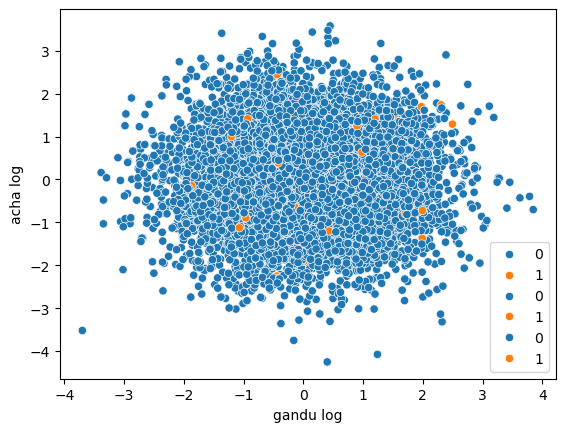

In [ ]:
import seaborn as sns
sns.scatterplot(x=df[0],y=df[1],hue=y)
plt.ylabel('acha log')
plt.xlabel('gandu log')
plt.show();

In [46]:
#hyper parameter turing
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
panelty = ['l1','l2','elasticnet']
c_vlaue = [100,10,1.0,0.1,0.01]
solvers = ['lbfgs','liblinear','newton-cg','newton-cholesky','sag','saga']
class_weight = [{0:w,1:y} for w in [1,5,10,20,25,35,50,75,100] for y in [1,5,10,20,25,35,50,75,100]]

In [47]:
parems = dict(penalty=panelty,C=c_vlaue,solver=solvers,class_weight=class_weight)
from sklearn.model_selection import StratifiedKFold
Cv=StratifiedKFold(n_splits=6)

In [48]:
from sklearn.model_selection import GridSearchCV
gridcv = GridSearchCV(estimator=model,param_grid=parems,scoring='accuracy',cv=Cv,n_jobs=-1)

In [49]:
gridcv.fit(x_train,y_train)

d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
24300 fits failed out of a total of 43740.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2430 fits failed with the following error:
Traceback (most recent call last):
  File "d:\test\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\test\anaconda3\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "d:\test\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py", line 1193, in fit
    solver = _check_solver(self.so

GridSearchCV(cv=StratifiedKFold(n_splits=6, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [100, 10, 1.0, 0.1, 0.01],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 5},
                                          {0: 1, 1: 10}, {0: 1, 1: 20},
                                          {0: 1, 1: 25}, {0: 1, 1: 35},
                                          {0: 1, 1: 50}, {0: 1, 1: 75},
                                          {0: 1, 1: 100}, {0: 5, 1: 1},
                                          {0: 5, 1: 5}, {0: 5, 1: 10},
                                          {0: 5, 1: 20}, {0: 5, 1: 25},
                                          {0: 5, 1: 35}, {0: 5, 1: 50},
                                          {0: 5, 1: 75}, {0: 5, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 5},
                                          {0: 10, 1: 10}, {0: 10, 1: 20},
                                          {0: 10, 1: 25}, {0: 10, 1: 35},
                                          {0: 10, 1: 50}, {0: 10, 1: 75},
                                          {0: 10, 1: 100}, {0: 20, 1: 1},
                                          {0: 20, 1: 5}, {0: 20, 1: 10}, ...],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['lbfgs', 'liblinear', 'newton-cg',
                                    'newton-cholesky', 'sag', 'saga']},
             scoring='accuracy')

In [50]:
gridcv.best_estimator_

LogisticRegression(C=100, class_weight={0: 25, 1: 75}, penalty='l1',
                   solver='liblinear')